In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn scipy nltk sentence-transformers

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 42

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **CS105 Final Project**

## Phase 2: Supervised Learning
The purpose of this project is to use the corpus created in Phase 1 for supervised learning to analyze and measure the document.
* We will read and tokenize the documents.
* Vectorize the corpus using Bag-of-Words (BoW) or one-hot encoding (OHE).
* Apply TF-IDF to the BoW representation, and compare the results with the original BoW representation for
at least some tasks.

## Preparing Data

Read the corpus from phase 1 and drop the incomplete row.

In [ ]:
# Loading data
df = pd.read_csv("AllCorpus.csv")
print(df.shape)

# Drop empty rows
df = df.dropna()
df.head()
print(df.shape)


(650, 5)
(553, 5)


## Converting the documents

### Tokenize the text
* We clean the text column by making each word to lowercase and remove all the symbol.
* Then spilt each word and tokenize them.


In [ ]:
# standardize the text and remove signs
def clean(text):
  text = text.lower()
  text = re.sub(r'[^a-z0-9\s]', '', text)
  tokens = text.split()
  return str(tokens)
  #return

df['text'] = df['text'].apply(clean)
df.head()

,doc_id,text,category_1,category_2,sentiment
0,1,"['trumps', 'presidency', 'has', 'been', 'tatte...",1,none,Negative
1,2,"['my', 'machine', 'learning', 'course', 'has',...",2,none,Positive
2,3,"['the', 'plot', 'of', 'the', 'final', 'season'...",3,none,Negative
3,4,"['i', 'enjoy', 'getting', 'learning', 'about',...",4,none,Positive
4,5,"['its', 'concerning', 'our', 'government', 'is...",1,2,Negative


### Vectorization

* remove the common english word use for filler without any meaning
* Generate the matrixes with three different ways for training models.
* convert to dataframe with each words apears/frequency/weight for each corpus.

In [ ]:
# remove common filler words
bow_vectorizer = CountVectorizer(stop_words="english")
binary_vectorizer = CountVectorizer(stop_words="english", binary=True)
tfidf_vectorizer = TfidfVectorizer(stop_words="english")

# count the amount of time each word appears
X_bow = bow_vectorizer.fit_transform(df["text"])

# One-hot Encoded, track if the word exist
X_binary = binary_vectorizer.fit_transform(df["text"])

# score a word to the dataset - weight
X_tfidf = tfidf_vectorizer.fit_transform(df["text"])

bow_df = pd.DataFrame(X_bow.toarray(), columns=bow_vectorizer.get_feature_names_out())
binary_df = pd.DataFrame(X_binary.toarray(), columns=binary_vectorizer.get_feature_names_out())
tfidf_df = pd.DataFrame(np.round(X_tfidf.toarray(), 2), columns=tfidf_vectorizer.get_feature_names_out())

print(bow_df.head())
print(binary_df.head())
print(tfidf_df.head())

#print(bow_df.shape)
#print(binary_df.shape)
#print(tfidf_df.shape)



   10  111  12  2026  2028  30  5k  5star  74  80  ...  yard  ye  year  years  \
0   0    0   0     0     0   0   0      0   0   0  ...     0   0     0      0   
1   0    0   0     0     0   0   0      0   0   0  ...     0   0     0      0   
2   0    0   0     0     0   0   0      0   0   0  ...     0   0     0      0   
3   0    0   0     0     0   0   0      0   0   0  ...     0   0     0      0   
4   0    0   0     0     0   0   0      0   0   0  ...     0   0     0      0   

   yesterdays  yoga  young  younger  youtube  zoomies  
0           0     0      0        0        0        0  
1           0     0      0        0        0        0  
2           0     0      0        0        0        0  
3           0     0      0        0        0        0  
4           0     0      0        0        0        0  

[5 rows x 2741 columns]
   10  111  12  2026  2028  30  5k  5star  74  80  ...  yard  ye  year  years  \
0   0    0   0     0     0   0   0      0   0   0  ...     0   0     0 

## Supervised Learning

* Clearly describe each task. For each task: implement the methods, run experiments, and analyze the results.

* For distance-based methods, use cosine similarity where appropriate. For at least two techniques, compare cosine
similarity with binary feature presence representations. Include visualizations where appropriate

### Logistic Regression

Accuracy:  0.7266187050359713
              precision    recall  f1-score   support

           1       0.86      0.82      0.84        39
           2       0.77      0.75      0.76        32
           3       0.68      0.58      0.62        26
           4       0.64      0.84      0.72        25
           5       0.56      0.53      0.55        17

    accuracy                           0.73       139
   macro avg       0.70      0.70      0.70       139
weighted avg       0.73      0.73      0.73       139



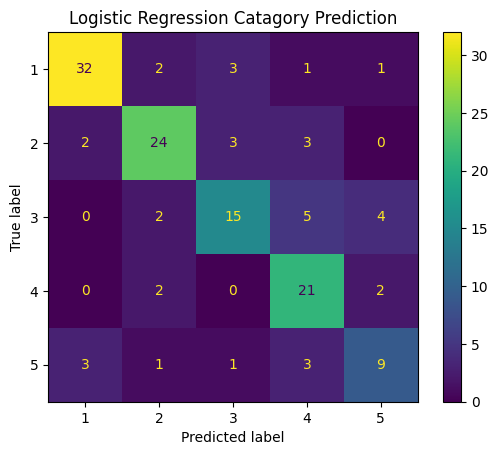

In [ ]:
lin_model = LogisticRegression(max_iter = 200, random_state = RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X_bow,
    df["category_1"],
    test_size = 0.25,
    random_state=RANDOM_STATE,
    stratify=df["category_1"]
)

lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division = 0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Logistic Regression Catagory Prediction")
plt.show()

**Analyze**:

### K-Nearest Neighbors (kNN)

Accuracy:  0.6618705035971223
              precision    recall  f1-score   support

           1       0.72      0.79      0.76        39
           2       0.65      0.69      0.67        32
           3       0.71      0.46      0.56        26
           4       0.59      0.80      0.68        25
           5       0.64      0.41      0.50        17

    accuracy                           0.66       139
   macro avg       0.66      0.63      0.63       139
weighted avg       0.67      0.66      0.65       139



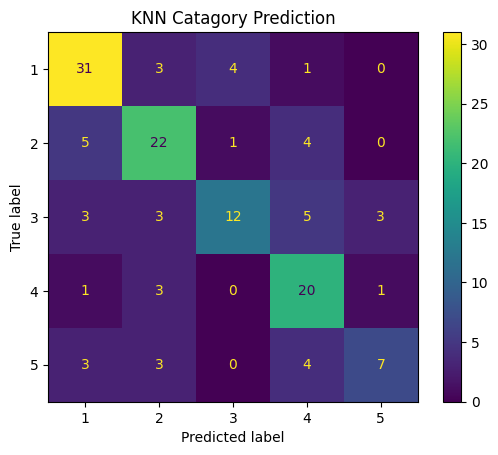

In [ ]:
# Used this source for making kNN algorithm: https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbor-algorithm-in-python/
y = df["category_1"]

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

knn = KNeighborsClassifier(n_neighbors=3, metric="cosine")
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("KNN Catagory Prediction")
plt.show()

**Analyze**:

### choose the model

Two additional supervised methods of your choice, for example, Naive Bayes, Support Vector Machines
(SVM), Decision Trees, Random Forest (or repeat the two techniques above, but for different tasks)

**Analyze**:

### choose the model

Two additional supervised methods of your choice, for example, Naive Bayes, Support Vector Machines
(SVM), Decision Trees, Random Forest (or repeat the two techniques above, but for different tasks)

**Analyze**:

## Group Contrubution


* Andrew Maciborski:
* Vincent Chau:
* Lyda Taing:
* Christie Wong:
* Daniel Remedios:

In [ ]:
#submisson
#!sudo apt-get update
#!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
#!pip install pypandoc
#!jupyter nbconvert --log-level DEBUG --to pdf "Final_Project_Phase2.ipynb"